# SUPPORT VECTOR MACHINE

## Task 1: Exploratory Data Analysis (EDA)

**1. Load the dataset and perform fundamental data exploration.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/Pharma_Industry (1).csv')
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (500, 6)


In [5]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [6]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [7]:
df['Drug Response'].value_counts()

Drug Response
1    260
0    240
Name: count, dtype: int64

In [8]:
df['Drug Response'].value_counts(normalize=True)*100

Drug Response
1    52.0
0    48.0
Name: proportion, dtype: float64

In [9]:
df.duplicated().sum()

0

The dataset contains 500 patient records with 5 numerical predictor variables and 1 binary target variable representing drug response (0 = No Response, 1 = Positive Response). All predictor variables are continuous and include drug dosage, systolic blood pressure, heart rate, liver toxicity index, and blood glucose level.

**2. Utilize histograms, box plots, or density plots to understand feature distributions**

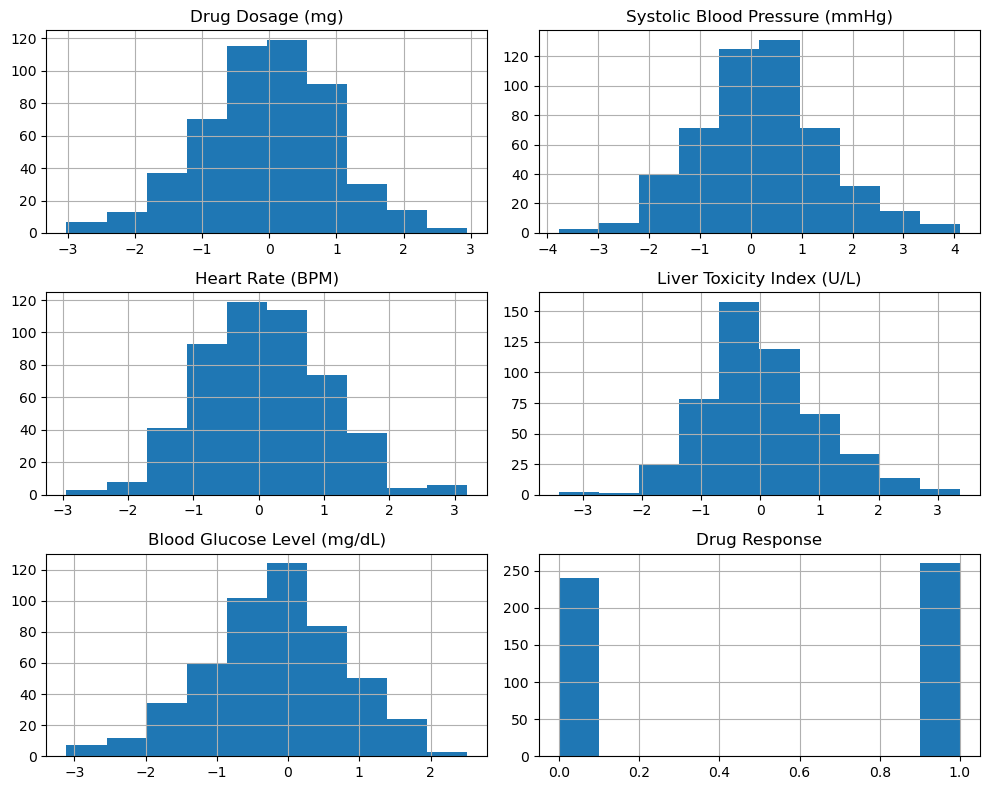

In [10]:
df.hist(figsize=(10,8), bins=10)
plt.tight_layout()
plt.show()

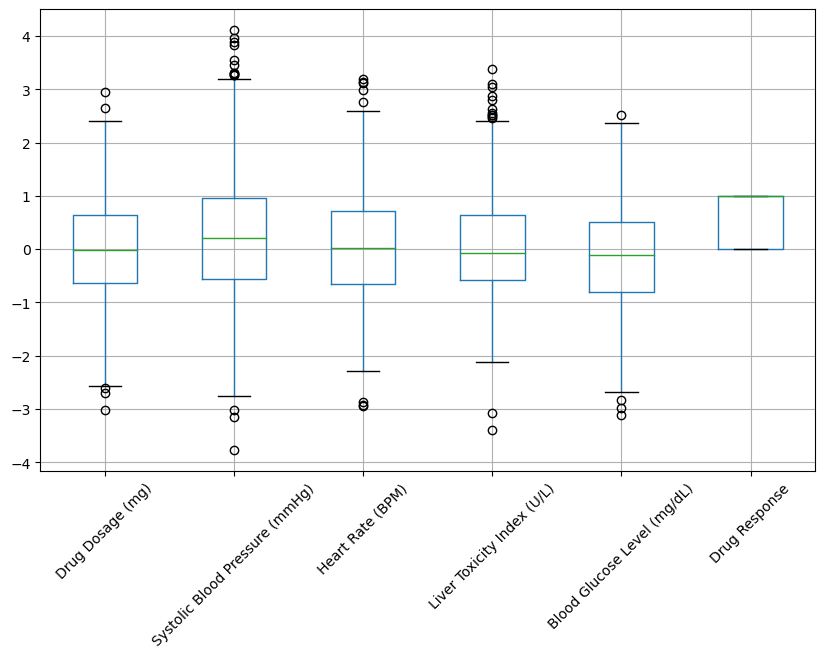

In [11]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

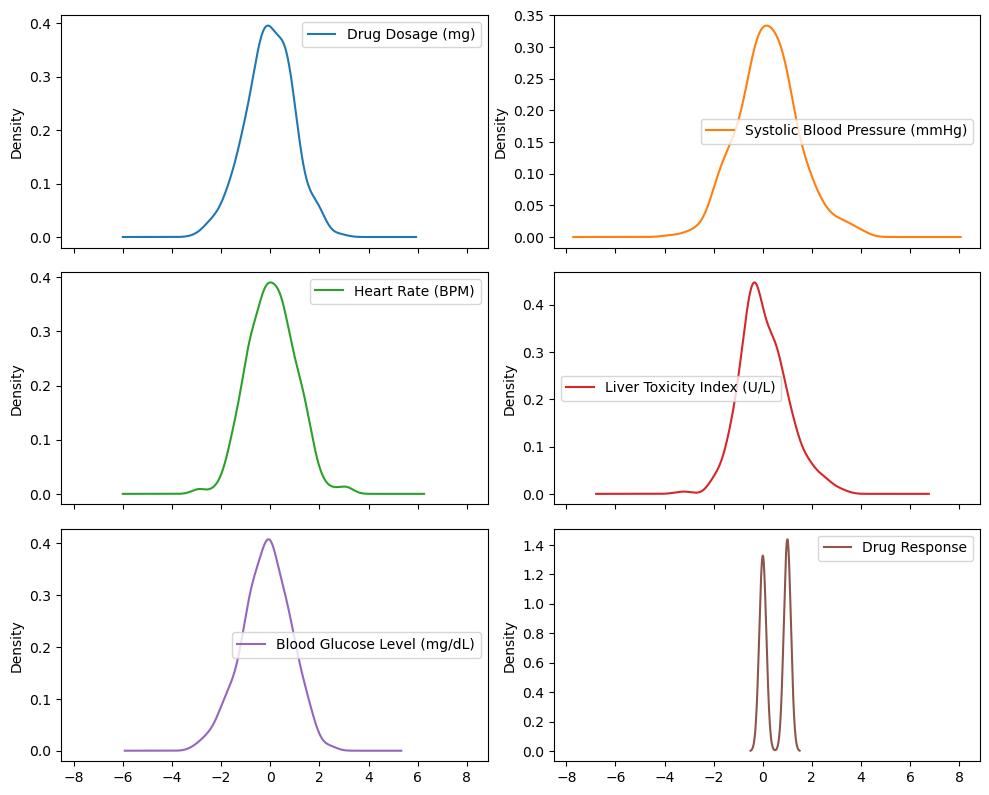

In [13]:
df.plot(kind='density', subplots=True, layout=(3,2), figsize=(10,8))
plt.tight_layout()
plt.show()

The exploratory visualizations indicate that most numerical features, including Drug Dosage, Systolic Blood Pressure, Heart Rate, Liver Toxicity Index, and Blood Glucose Level, follow approximately normal (bell-shaped) distributions centered around zero. This suggests that the dataset appears to be standardized or normally distributed.

Boxplots reveal the presence of a few mild outliers across some physiological measurements, particularly in Systolic Blood Pressure and Liver Toxicity Index.

The density plots further confirm that the features are symmetrically distributed with moderate spread and no severe skewness. The target variable (Drug Response) shows a binary distribution, indicating the classification nature of the problem.

**3.Investigate feature correlations to discern relationships within the data.**

In [15]:
corr_matrix = df.corr()

corr_matrix

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


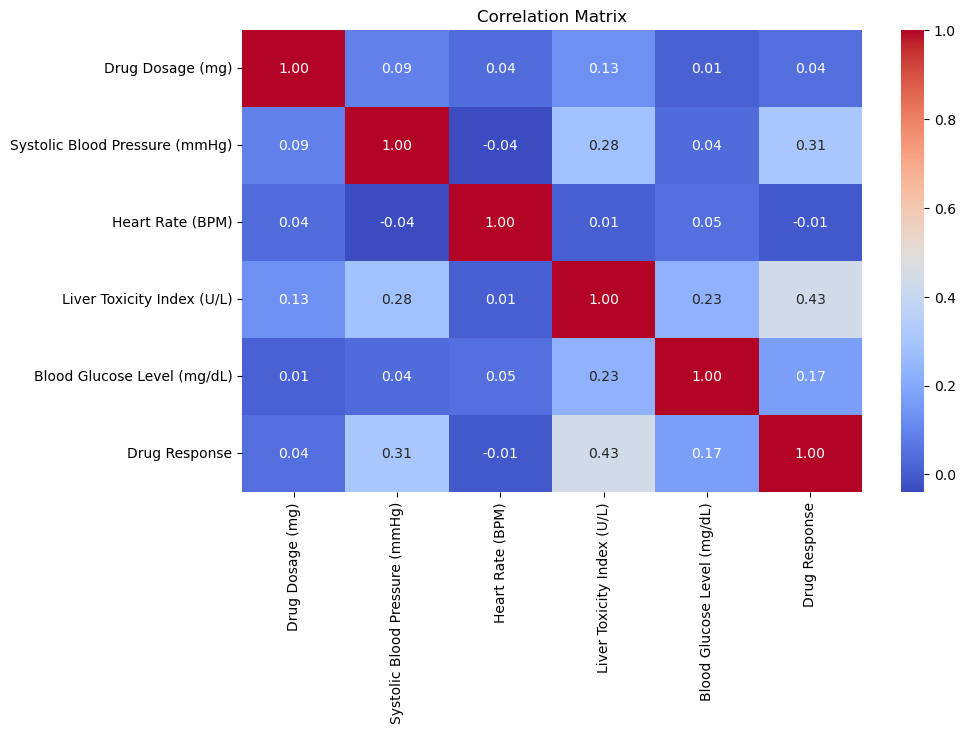

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

The correlation analysis shows that Liver Toxicity Index (r = 0.43) has the strongest positive relationship with Drug Response, making it the most influential predictor. Systolic Blood Pressure (r = 0.31) also shows a moderate positive correlation with the target variable.

Blood Glucose Level has a weak positive correlation, while Drug Dosage and Heart Rate show negligible relationships with Drug Response. Additionally, no strong correlations exist among independent variables, indicating no multicollinearity concerns in the dataset.

## Task 2: Data Preprocessing

**1. Encode categorical variables if necessary.**

In [17]:
df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

The dataset does not contain any categorical variables. All predictor variables are numerical, and the target variable (Drug Response) is already encoded in binary format (0 = No Response, 1 = Positive Response). Therefore, no categorical encoding was required.

**2. Split the dataset into training and testing sets.**

In [18]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

In [20]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (400, 5)
Testing set shape: (100, 5)


The dataset was divided into training and testing sets using an 80-20 split. The train_test_split() function from scikit-learn was used with random_state=42.Stratified sampling was applied to maintain equal class distribution of the target variable (Drug Response) in both training and testing sets.

## Task 3: Data Visualization

**1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.**


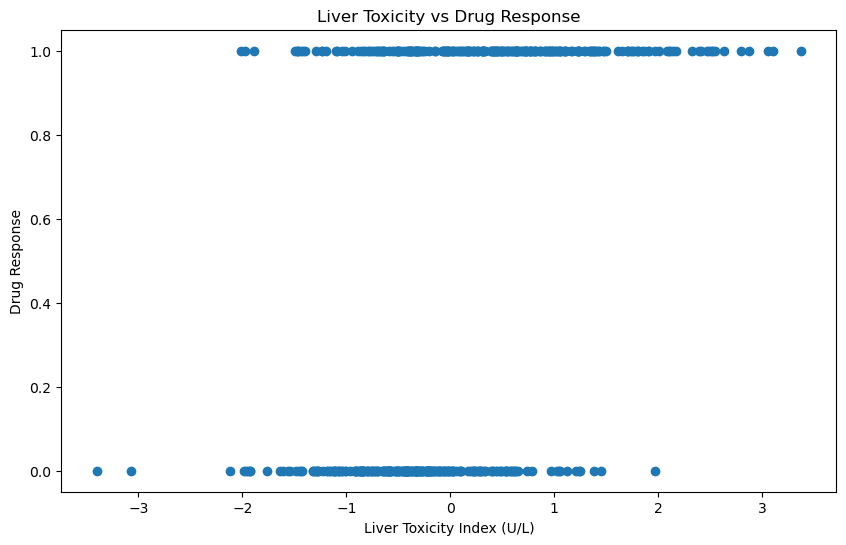

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(df['Liver Toxicity Index (U/L)'], df['Drug Response'])
plt.xlabel('Liver Toxicity Index (U/L)')
plt.ylabel('Drug Response')
plt.title("Liver Toxicity vs Drug Response")
plt.show()

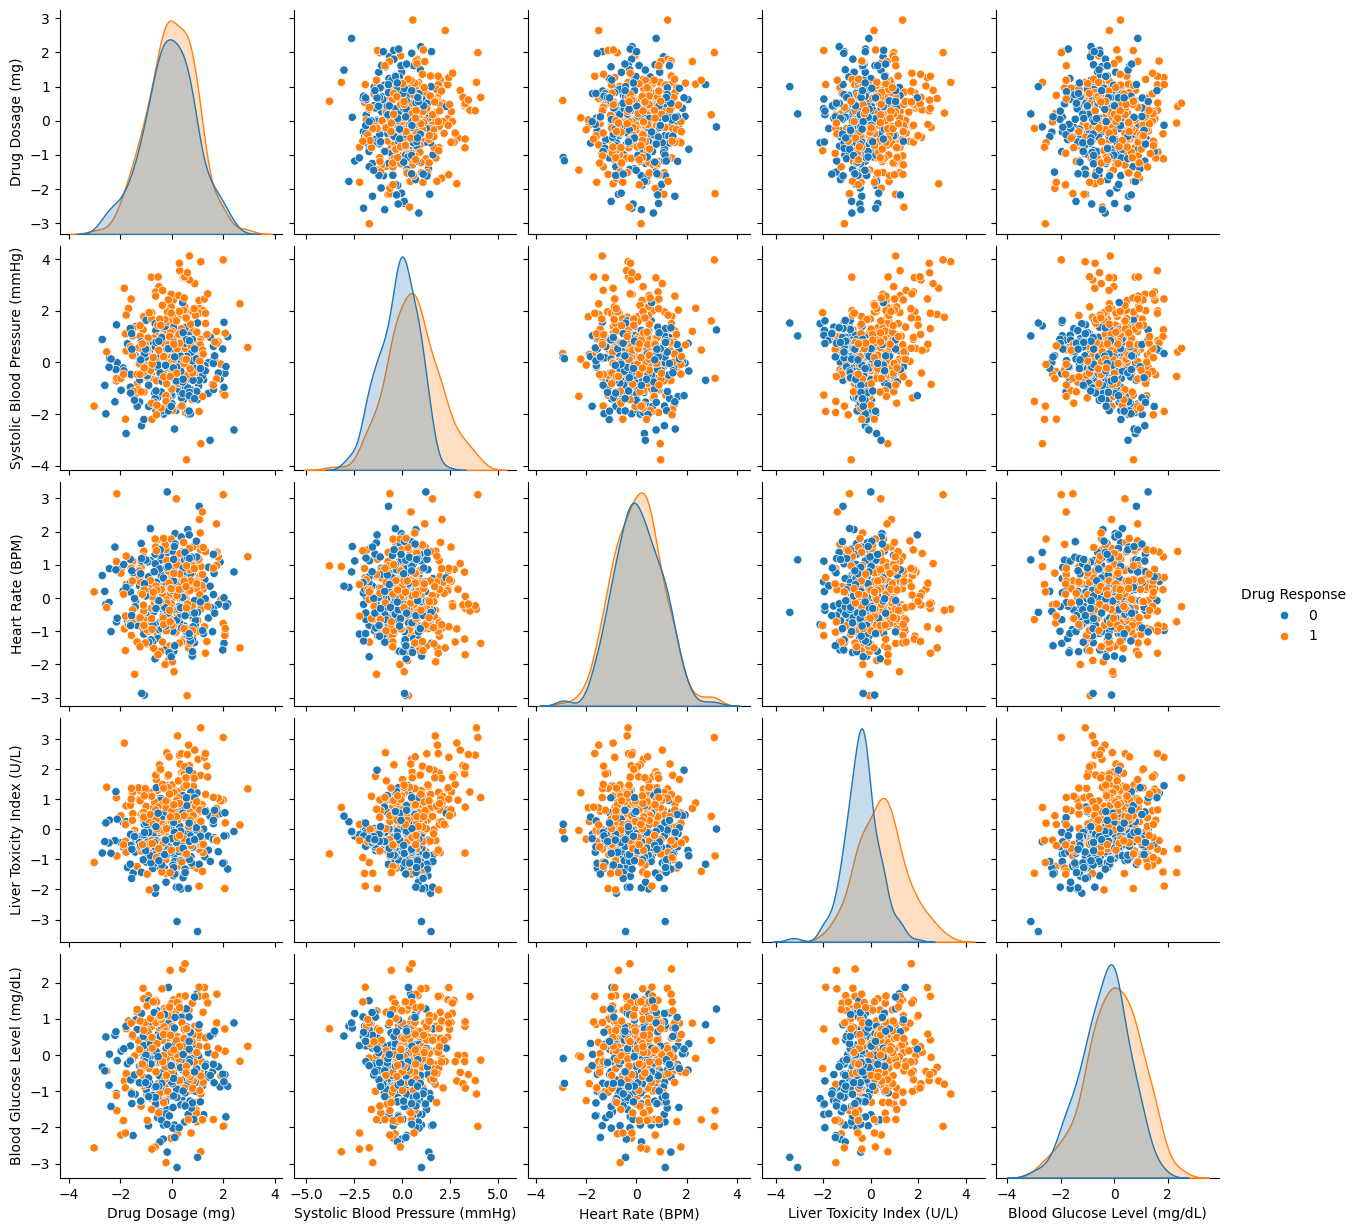

In [26]:
sns.pairplot(df,hue='Drug Response')
plt.show()

The scatter plot of Liver Toxicity Index vs Drug Response shows clearer separation between responders (1) and non-responders (0), supporting earlier correlation findings that liver toxicity has the strongest relationship with drug effectiveness.

The pair plot further indicates that Systolic Blood Pressure and Liver Toxicity Index show moderate differentiation between the two classes, while features such as Drug Dosage and Heart Rate display significant overlap between responders and non-responders.

**2. Visualize class distributions to gauge dataset balance or imbalance.**

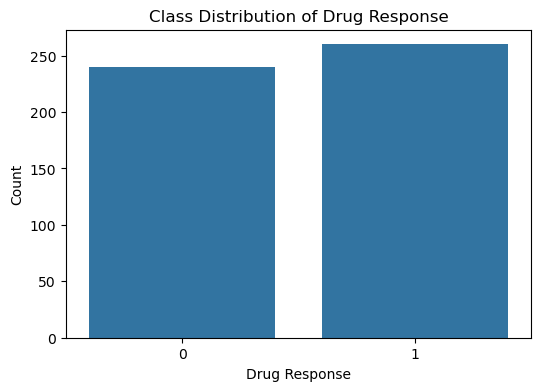

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Drug Response', data=df)
plt.title("Class Distribution of Drug Response")
plt.xlabel('Drug Response')
plt.ylabel("Count")
plt.show()

The class distribution visualization indicates that the dataset is reasonably balanced between patients who responded positively to the drug and those who did not. Since both classes are represented in comparable proportions, the dataset does not suffer from significant class imbalance.

## Task 4: SVM Implementation

**1.	Implement a basic SVM classifier using Python libraries like scikit-learn.**

**2.Train the SVM model on the training data.**


In [28]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ('scaler',StandardScaler()),
    ('svm',SVC(kernel='rbf', random_state=42))
])

In [29]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(random_state=42))])

A Support Vector Machine (SVM) classifier was implemented using the scikit-learn library. Since SVM is sensitive to feature scaling, StandardScaler was applied using a pipeline to standardize the features before training.

**3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).** 

In [30]:
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score

y_pred = svm_model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.77
Precision: 0.754
Recall: 0.827
F1 Score: 0.789


The SVM classifier achieved an accuracy of 77%, indicating good overall predictive performance. The precision of 0.754 shows that approximately 75% of the patients predicted as positive responders were correctly classified. The recall of 0.827 indicates that the model successfully identified about 83% of actual positive responders, demonstrating strong sensitivity.The F1-score of 0.789 reflects a good balance between precision and recall.

## Task 5: Visualization of SVM Results

**1. Visualize classification results on the testing data.**

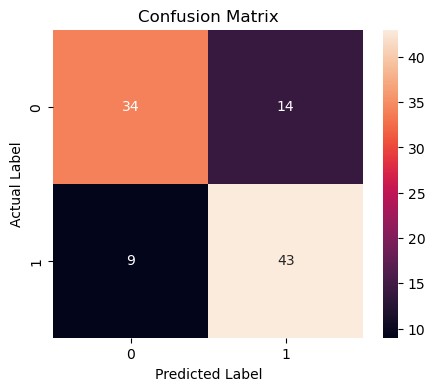

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted Label")
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows that the SVM model correctly classified 34 non-responders (True Negatives) and 43 positive responders (True Positives). However, it incorrectly predicted 14 non-responders as responders (False Positives) and failed to identify 9 actual responders (False Negatives).

## Task 6: Parameter Tuning and Optimization

**1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.**

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [36]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

In [40]:
param_grid = {
    "svm__C":[0.1,1,10,100],
    'svm__kernel':['linear','rbf','poly'],
    'svm__gamma':['scale','auto']
}

In [41]:
grid_search = GridSearchCV(pipeline, param_grid,cv=5, scoring='accuracy')

In [42]:
%time grid_search.fit(X_train,y_train)

CPU times: total: 4.52 s
Wall time: 4.63 s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': ['scale', 'auto'],
                         'svm__kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [43]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best Cross-Validation Score: 0.7525000000000001


In [44]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Tuned Test Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Test Accuracy: 0.77


The hyperparameter tuning using GridSearchCV identified the optimal SVM configuration as RBF kernel with C = 1 and gamma = 'scale'. The best cross-validation accuracy achieved was 75.25%, indicating stable performance across different training folds. When evaluated on the testing data, the tuned model achieved an accuracy of 77%,

## Task 7: Comparison and Analysis

**1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).**


In [45]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

kernels = ["linear", "poly", "rbf"]

results = {}

for k in kernels:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=k, C=1, gamma="scale", random_state=42))
    ])
    
    model.fit(X_train, y_train)
    y_pred_kernel = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred_kernel)
    results[k] = acc

results


{'linear': 0.72, 'poly': 0.65, 'rbf': 0.77}

The performance comparison of different SVM kernels shows that the RBF kernel achieved the highest accuracy (77%), indicating superior ability to capture non-linear relationships within the dataset. The linear kernel achieved 72% accuracy, suggesting that while the data has some linear structure, it is not entirely linearly separable.

The polynomial kernel performed the lowest (65%), indicating that it may not effectively model the underlying patterns or may introduce unnecessary complexity. Overall, the results suggest that the relationship between physiological features and drug response is non-linear, making the RBF kernel the most appropriate choice for this classification problem.

**2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.**

**Strengths of SVM:**

* Effective in Non-Linear Classification: The RBF kernel successfully captured complex relationships between biological features and drug response, leading to the highest accuracy (77%).

* Robust to High-Dimensional Data: Although this dataset has only five features, SVM efficiently handled feature interactions without overfitting.

* Good Generalization: Cross-validation results were consistent with test accuracy.

* Margin Maximization: SVM maximizes the margin between classes, making it effective in handling overlapping physiological data.

**Weaknesses of SVM:**

* Limited Interpretability: SVM does not provide easily interpretable feature importance.

* Sensitive to Hyperparameters: Model performance depends heavily on selecting appropriate values for C, kernel type, and gamma.

* Computational Cost: SVM can become computationally expensive for very large datasets, though manageable in this case (500 samples). 


**3. Discuss practical implications of SVM in real-world classification tasks.**

1. Fraud Detection (Banking & Finance)

SVM is used to detect fraudulent transactions by identifying unusual spending patterns. Its ability to create clear decision boundaries helps separate legitimate and suspicious activities.

2. Credit Risk Assessment

Financial institutions use SVM to classify customers as low-risk or high-risk borrowers based on financial history and behavioral features.

3. Spam and Text Classification

SVM is highly effective in email spam detection and sentiment analysis because it performs well with high-dimensional text data.

4. Image and Face Recognition

In computer vision, SVM is used for object detection and face recognition by classifying pixel-based feature vectors.

5. Manufacturing and Quality Control

Industries use SVM to classify defective vs. non-defective products based on sensor or production line data.